In [60]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [61]:
df = pd.read_csv('loan_sanction_test.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


# cleaning the dataset

In [62]:
df = df.drop(['Loan_ID','Gender','Dependents','Married','Self_Employed','CoapplicantIncome','Loan_Amount_Term','Credit_History','Property_Area'], axis=1)
df.head()

,Education,ApplicantIncome,LoanAmount
0,Graduate,5720,110.0
1,Graduate,3076,126.0
2,Graduate,5000,208.0
3,Graduate,2340,100.0
4,Not Graduate,3276,78.0


In [63]:
df.isnull().sum()


Education          0
ApplicantIncome    0
LoanAmount         5
dtype: int64

In [64]:
df = df.fillna(df['LoanAmount'].mean())

In [65]:
df.isnull().sum()

Education          0
ApplicantIncome    0
LoanAmount         0
dtype: int64

In [66]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Education'] = le.fit_transform(df['Education']) # graduate = 0, not graduate = 1
df.head()

,Education,ApplicantIncome,LoanAmount
0,0,5720,110.0
1,0,3076,126.0
2,0,5000,208.0
3,0,2340,100.0
4,1,3276,78.0


In [67]:
x = df[['ApplicantIncome','Education']]
y = df['LoanAmount']

In [68]:
x.head()

,ApplicantIncome,Education
0,5720,0
1,3076,0
2,5000,0
3,2340,0
4,3276,1


In [69]:
y.head()

0    110.0
1    126.0
2    208.0
3    100.0
4     78.0
Name: LoanAmount, dtype: float64

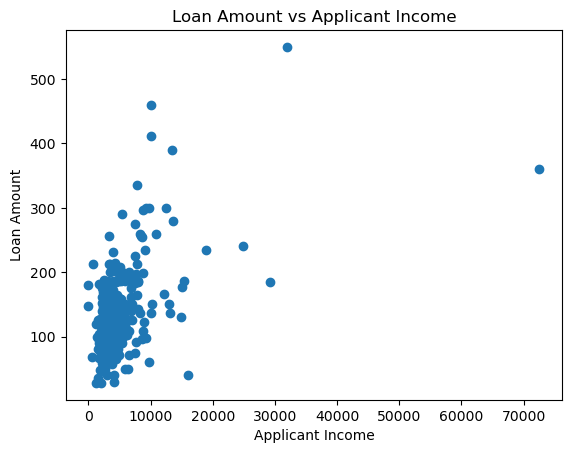

In [78]:
plt.scatter(df['ApplicantIncome'], df['LoanAmount'])
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount')
plt.title('Loan Amount vs Applicant Income')
plt.show()

# performing model implementation


In [70]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [71]:
model = LinearRegression()


In [72]:
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [73]:
y_pred = model.predict(x_test)
y_pred

array([110.07059606, 124.97036021, 141.53113919, 122.57582317,
       129.73646512, 131.95873331, 127.30173201, 113.14697467,
       137.70102838, 146.31447098, 124.051593  , 129.90873397,
       137.93646247, 124.78086448, 120.55453531, 195.04932921,
       141.83548082, 126.11307693, 164.68407289, 121.97862448,
       108.61205311, 107.85407016, 132.4353438 , 132.01615626,
       117.4724144 , 142.48436017, 121.42736416, 111.2994472 ,
       122.09921268, 132.86601593, 108.98955304, 134.82988084,
       104.87956132, 125.35658553, 136.52960018, 132.91769659,
       121.05411498, 131.43618446, 148.37021261, 136.03002051,
       129.14500873, 105.12073771, 109.05995213, 132.64780872,
       120.80294554, 121.3756835 , 127.29598972, 120.10812784,
       107.26261377, 133.45173003, 152.63099555, 142.11685328,
       166.41250371, 104.28810493, 109.18628262, 133.87091757,
       122.19832324, 122.4265235 , 122.01882055, 145.48758049,
       130.23753633, 123.34529071, 128.58800611, 118.73

In [74]:
print('mae:', mean_absolute_error(y_test, y_pred))
print('mse:', mean_squared_error(y_test,y_pred))
print('r2 score:', r2_score(y_test,y_pred))

mae: 36.52810296353118
mse: 3057.323791856628
r2 score: 0.11868514141620135


In [75]:
model.predict([[4500,0]])

array([134.82988084])